In [2]:
# Import Dependencies

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_recall_fscore_support

In [3]:
# Paths

root = "/kaggle/input/breast-cancer-detection-mri/Breast_Cancer_MRI_Dataset"
IMG_SIZE = 512
BATCH = 16
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 1    # binary (pos / neg)
PATCH_SIZE = 4     # H*W patches from CNN feature map
EMBED_DIM = 128    # transformer embedding dim
NUM_HEADS = 4
TRANSFORMER_DEPTH = 4
MLP_DIM = 256
DROPOUT = 0.1

## Load dataset

In [4]:
# Load dataset

def build_ds(subdir, augment=False, shuffle=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(root, subdir),
        labels="inferred",
        label_mode="int",
        color_mode="rgb",
        batch_size=BATCH,
        image_size=IMG_SIZE,
        shuffle=shuffle,
        seed=SEED
    )

    aug = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.05),
        layers.RandomContrast(0.1),
        layers.RandomZoom(0.1)
    ]) if augment else None

    def _map(x, y):
        x = tf.cast(x, tf.float32) / 255.0
        if aug is not None:
            x = aug(x, training=True)
            
        # x = layers.Rescaling(1./255)(x)
        return x, y

    return (ds.map(_map, num_parallel_calls=AUTOTUNE)
              .cache()
              .prefetch(AUTOTUNE))

train_ds = build_ds("train", augment=True, shuffle=True)
val_ds   = build_ds("validation", augment=False, shuffle=False)
test_ds  = build_ds("test", augment=False, shuffle=False)

Found 4000 files belonging to 2 classes.


I0000 00:00:1765301819.422902     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765301819.423486     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 400 files belonging to 2 classes.
Found 400 files belonging to 2 classes.


## CNN backbone

In [14]:
def cnn_backbone(inputs):
    # --- Block 1 ---
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)  # 512 -> 256

    # --- Block 2 ---
    shortcut = layers.Conv2D(64, 1, padding="same")(x)  # match channels
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.MaxPooling2D(2)(x)  # 256 -> 128

    # --- Block 3 ---
    shortcut = layers.Conv2D(128, 1, padding="same")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.MaxPooling2D(2)(x)  # 128 -> 64

    # --- Optional Block 4 ---
    shortcut = layers.Conv2D(256, 1, padding="same")(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.MaxPooling2D(2)(x)  # 64 -> 32

    return x

## ViT

In [15]:
class PatchExtractor(layers.Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim

    def build(self, input_shape):
        # input_shape: (B, H, W, C)
        self.proj = layers.Dense(self.embed_dim)

    def call(self, images):
        # images: (B, H, W, C)
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dim = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])
        patches = self.proj(patches)  # project to embed_dim
        return patches

class ClsTokenLayer(layers.Layer):
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, self.embed_dim),
            initializer="zeros",
            trainable=True,
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls_tokens = tf.repeat(self.cls_token, repeats=batch_size, axis=0)
        return tf.concat([cls_tokens, x], axis=1)

class AddPositionEmbedding(layers.Layer):
    def __init__(self, max_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.max_patches = max_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        # create (1, max_patches+1, D)
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(1, self.max_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, x):
        seq_len = tf.shape(x)[1]         # dynamic
        return x + self.pos_embed[:, :seq_len, :]


def transformer_block(x, embed_dim, num_heads, mlp_dim, dropout, l2=1e-5):
    y = layers.LayerNormalization(epsilon=1e-6)(x)
    y = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim//num_heads, dropout=dropout)(y, y)
    y = layers.Dropout(dropout)(y)
    x = layers.Add()([x, y])

    y = layers.LayerNormalization(epsilon=1e-6)(x)
    y = layers.Dense(mlp_dim, activation="gelu", kernel_regularizer=keras.regularizers.l2(l2))(y)
    y = layers.Dropout(dropout)(y)
    y = layers.Dense(embed_dim, kernel_regularizer=keras.regularizers.l2(l2))(y)
    y = layers.Dropout(dropout)(y)
    x = layers.Add()([x, y])
    return x

## Build CNN-ViT hybrid model

In [16]:
def build_cnn_vit_hybrid(
    img_size=512,        # can be int or tuple
    patch_size=4,
    embed_dim=128,
    num_heads=4,
    transformer_depth=3,
    mlp_dim=256,
    dropout=0.1
):
    # handle img_size
    if isinstance(img_size, (tuple, list)):
        H, W = img_size[0], img_size[1]
    else:
        H = W = img_size   # if int, use square image

    inputs = keras.Input(shape=(H, W, 3))
    feature_map = cnn_backbone(inputs)

    # patches + projection
    patches = PatchExtractor(patch_size, embed_dim)(feature_map)
    tokens = ClsTokenLayer(embed_dim)(patches)

    # compute max_patches
    fm_h, fm_w = feature_map.shape[1] or H//16, feature_map.shape[2] or W//16
    max_patches = (fm_h // patch_size) * (fm_w // patch_size)
    tokens = AddPositionEmbedding(max_patches, embed_dim)(tokens)

    # transformer encoder
    x = tokens
    for _ in range(transformer_depth):
        x = transformer_block(x, embed_dim, num_heads, mlp_dim, dropout)

    cls_out = layers.LayerNormalization(epsilon=1e-6)(x[:, 0, :])

    # classification head
    x = layers.Dropout(dropout)(cls_out)
    x = layers.Dense(128, activation="gelu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(64, activation="gelu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="cnn_vit_hybrid_small_dataset")
    return model


model = build_cnn_vit_hybrid(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    transformer_depth=TRANSFORMER_DEPTH,
    mlp_dim=MLP_DIM,
    dropout=DROPOUT
)

model.summary()

Model: "cnn_vit_hybrid_small_dataset"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 512, 512,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 512, 512,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │      2,112 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ add_1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 128, 128,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_11[0][0] 

 Total params: 2,307,425 (8.80 MB)

 Trainable params: 2,305,505 (8.79 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [17]:
# Warmup + CosineDecay schedule
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps=1000, alpha=0.0):
        super().__init__()
        self.base_lr = base_lr
        self.total_steps = tf.cast(total_steps, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.alpha = alpha

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        # linear warmup
        warmup_lr = self.base_lr * (step / tf.maximum(1.0, self.warmup_steps))
        # cosine decay
        progress = (step - self.warmup_steps) / tf.maximum(1.0, (self.total_steps - self.warmup_steps))
        cosine_lr = self.alpha + (1.0 - self.alpha) * 0.5 * (1 + tf.cos(tf.constant(3.1415926535) * tf.clip_by_value(progress, 0.0, 1.0)))
        cosine_lr = self.base_lr * cosine_lr
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)
    
    def get_config(self):
        # Needed for saving/loading the schedule
        return {
            "base_lr": self.base_lr.numpy() if isinstance(self.base_lr, tf.Variable) else self.base_lr,
            "total_steps": float(self.total_steps.numpy()) if isinstance(self.total_steps, tf.Variable) else float(self.total_steps),
            "warmup_steps": float(self.warmup_steps.numpy()) if isinstance(self.warmup_steps, tf.Variable) else float(self.warmup_steps),
            "alpha": self.alpha
        }

# steps
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
total_steps = steps_per_epoch * 40   # plan 40 epochs
warmup_steps = max(100, steps_per_epoch)  # at least 1 epoch of warmup

lr_schedule = WarmUpCosine(base_lr=3e-4, total_steps=total_steps, warmup_steps=warmup_steps, alpha=1e-4)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")]
)


## Train

In [18]:
class PrintLR(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        # current step from optimizer
        step = tf.keras.backend.get_value(self.model.optimizer.iterations)

        # get the schedule object
        lr_schedule = self.model.optimizer.learning_rate

        # compute LR for this step
        if callable(lr_schedule):
            lr = float(lr_schedule(step))
        else:
            lr = float(tf.keras.backend.get_value(lr_schedule))

        print(f"Epoch {epoch+1}: lr = {lr:.8f}")


callbacks = [
    PrintLR(),
    keras.callbacks.ModelCheckpoint("/kaggle/working/CNN-ViT.keras",
                                    monitor="val_accuracy", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True)
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1: lr = 0.00000000
Epoch 1/100


I0000 00:00:1765302176.622838     810 service.cc:148] XLA service 0x7b77b8012da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765302176.622886     810 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765302176.622891     810 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765302179.748821     810 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-12-09 17:43:11.516532: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng12{k11=0} for conv (f32[16,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.5775 - auc: 0.6146 - loss: 0.7185
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /kaggle/working/CNN-ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 216s 560ms/step - accuracy: 0.5777 - auc: 0.6148 - loss: 0.7183 - val_accuracy: 0.5000 - val_auc: 0.5817 - val_loss: 0.9173
Epoch 2: lr = 0.00030000
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.7251 - auc: 0.7922 - loss: 0.5959
Epoch 2: val_accuracy improved from 0.50000 to 0.54750, saving model to /kaggle/working/CNN-ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 439ms/step - accuracy: 0.7252 - auc: 0.7922 - loss: 0.5958 - val_accuracy: 0.5475 - val_auc: 0.8851 - val_loss: 0.7348
Epoch 3: lr = 0.00029951
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.7837 - auc: 0.8535 - loss: 0.5237
Epoch 3: val_accuracy improved from 0.54750 to 0.87000, saving model to /kaggle/working/CNN-ViT.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 439ms/step

## Fine tune

In [20]:
class PrintLR(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        # current step from optimizer
        step = tf.keras.backend.get_value(self.model.optimizer.iterations)

        # get the schedule object
        lr_schedule = self.model.optimizer.learning_rate

        # compute LR for this step
        if callable(lr_schedule):
            lr = float(lr_schedule(step))
        else:
            lr = float(tf.keras.backend.get_value(lr_schedule))

        print(f"Epoch {epoch+1}: lr = {lr:.8f}")


callbacks = [
    PrintLR(),
    keras.callbacks.ModelCheckpoint("/kaggle/working/CNN-ViT_ft.keras",
                                    monitor="val_accuracy", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True)
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1: lr = 0.00010463
Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9466 - auc: 0.9851 - loss: 0.2270
Epoch 1: val_accuracy improved from -inf to 0.77750, saving model to /kaggle/working/CNN-ViT_ft.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 439ms/step - accuracy: 0.9466 - auc: 0.9851 - loss: 0.2271 - val_accuracy: 0.7775 - val_auc: 0.9312 - val_loss: 0.6254
Epoch 2: lr = 0.00009328
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9465 - auc: 0.9797 - loss: 0.2418
Epoch 2: val_accuracy improved from 0.77750 to 0.92250, saving model to /kaggle/working/CNN-ViT_ft.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 439ms/step - accuracy: 0.9465 - auc: 0.9797 - loss: 0.2417 - val_accuracy: 0.9225 - val_auc: 0.9520 - val_loss: 0.3268
Epoch 3: lr = 0.00008229
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9700 - auc: 0.9930 - loss: 0.1807
Epoch 3: val_accuracy improved from 0.92250 to 0.93750, saving model to /kaggle/working/CNN-ViT_ft.kera

In [31]:
model = keras.models.load_model(
    "/kaggle/working/CNN-ViT_ft.keras",
    custom_objects={
        "PatchExtractor": PatchExtractor,
        "ClsTokenLayer": ClsTokenLayer,
        "AddPositionEmbedding": AddPositionEmbedding,
        "transformer_block": transformer_block,
        "WarmUpCosine": WarmUpCosine
    }
)

# Warmup + CosineDecay schedule
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps=1000, alpha=0.0):
        super().__init__()
        self.base_lr = base_lr
        self.total_steps = tf.cast(total_steps, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.alpha = alpha

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        # linear warmup
        warmup_lr = self.base_lr * (step / tf.maximum(1.0, self.warmup_steps))
        # cosine decay
        progress = (step - self.warmup_steps) / tf.maximum(1.0, (self.total_steps - self.warmup_steps))
        cosine_lr = self.alpha + (1.0 - self.alpha) * 0.5 * (1 + tf.cos(tf.constant(3.1415926535) * tf.clip_by_value(progress, 0.0, 1.0)))
        cosine_lr = self.base_lr * cosine_lr
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)
    
    def get_config(self):
        # Needed for saving/loading the schedule
        return {
            "base_lr": self.base_lr.numpy() if isinstance(self.base_lr, tf.Variable) else self.base_lr,
            "total_steps": float(self.total_steps.numpy()) if isinstance(self.total_steps, tf.Variable) else float(self.total_steps),
            "warmup_steps": float(self.warmup_steps.numpy()) if isinstance(self.warmup_steps, tf.Variable) else float(self.warmup_steps),
            "alpha": self.alpha
        }

# steps
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
total_steps = steps_per_epoch * 40   # plan 40 epochs
warmup_steps = max(100, steps_per_epoch)  # at least 1 epoch of warmup

lr_schedule = WarmUpCosine(base_lr=3e-4, total_steps=total_steps, warmup_steps=warmup_steps, alpha=1e-4)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")]
)



class PrintLR(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        # current step from optimizer
        step = tf.keras.backend.get_value(self.model.optimizer.iterations)

        # get the schedule object
        lr_schedule = self.model.optimizer.learning_rate

        # compute LR for this step
        if callable(lr_schedule):
            lr = float(lr_schedule(step))
        else:
            lr = float(tf.keras.backend.get_value(lr_schedule))

        print(f"Epoch {epoch+1}: lr = {lr:.8f}")


callbacks = [
    PrintLR(),
    keras.callbacks.ModelCheckpoint("/kaggle/working/CNN-ViT_Best.keras",
                                    monitor="val_accuracy", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True)
]


history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1: lr = 0.00000000
Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9914 - auc: 0.9984 - loss: 0.1296
Epoch 1: val_accuracy improved from -inf to 0.95500, saving model to /kaggle/working/CNN-ViT_Best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 149s 451ms/step - accuracy: 0.9913 - auc: 0.9983 - loss: 0.1297 - val_accuracy: 0.9550 - val_auc: 0.9829 - val_loss: 0.2293
Epoch 2: lr = 0.00030000
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9561 - auc: 0.9876 - loss: 0.2119
Epoch 2: val_accuracy did not improve from 0.95500
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 438ms/step - accuracy: 0.9561 - auc: 0.9876 - loss: 0.2119 - val_accuracy: 0.9025 - val_auc: 0.9689 - val_loss: 0.3386
Epoch 3: lr = 0.00029951
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9639 - auc: 0.9906 - loss: 0.1913
Epoch 3: val_accuracy did not improve from 0.95500
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 437ms/step - accuracy: 0.9639 - auc: 0.9906 - loss: 0.1913 - val_accur

In [36]:
model = keras.models.load_model(
    "/kaggle/working/CNN-ViT_Best.keras",
    custom_objects={
        "PatchExtractor": PatchExtractor,
        "ClsTokenLayer": ClsTokenLayer,
        "AddPositionEmbedding": AddPositionEmbedding,
        "transformer_block": transformer_block,
        "WarmUpCosine": WarmUpCosine
    }
)

# Warmup + CosineDecay schedule
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps=1000, alpha=0.0):
        super().__init__()
        self.base_lr = base_lr
        self.total_steps = tf.cast(total_steps, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.alpha = alpha

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        # linear warmup
        warmup_lr = self.base_lr * (step / tf.maximum(1.0, self.warmup_steps))
        # cosine decay
        progress = (step - self.warmup_steps) / tf.maximum(1.0, (self.total_steps - self.warmup_steps))
        cosine_lr = self.alpha + (1.0 - self.alpha) * 0.5 * (1 + tf.cos(tf.constant(3.1415926535) * tf.clip_by_value(progress, 0.0, 1.0)))
        cosine_lr = self.base_lr * cosine_lr
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)
    
    def get_config(self):
        # Needed for saving/loading the schedule
        return {
            "base_lr": self.base_lr.numpy() if isinstance(self.base_lr, tf.Variable) else self.base_lr,
            "total_steps": float(self.total_steps.numpy()) if isinstance(self.total_steps, tf.Variable) else float(self.total_steps),
            "warmup_steps": float(self.warmup_steps.numpy()) if isinstance(self.warmup_steps, tf.Variable) else float(self.warmup_steps),
            "alpha": self.alpha
        }

# steps
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
total_steps = steps_per_epoch * 40   # plan 40 epochs
warmup_steps = max(100, steps_per_epoch)  # at least 1 epoch of warmup

lr_schedule = WarmUpCosine(base_lr=3e-4, total_steps=total_steps, warmup_steps=warmup_steps, alpha=1e-4)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")]
)



class PrintLR(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        # current step from optimizer
        step = tf.keras.backend.get_value(self.model.optimizer.iterations)

        # get the schedule object
        lr_schedule = self.model.optimizer.learning_rate

        # compute LR for this step
        if callable(lr_schedule):
            lr = float(lr_schedule(step))
        else:
            lr = float(tf.keras.backend.get_value(lr_schedule))

        print(f"Epoch {epoch+1}: lr = {lr:.8f}")


callbacks = [
    PrintLR(),
    keras.callbacks.ModelCheckpoint("/kaggle/working/CNN-ViT_FINAL.keras",
                                    monitor="val_accuracy", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True)
]


history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1: lr = 0.00000000
Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9980 - auc: 0.9996 - loss: 0.1009
Epoch 1: val_accuracy improved from -inf to 0.90750, saving model to /kaggle/working/CNN-ViT_FINAL.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 150s 451ms/step - accuracy: 0.9980 - auc: 0.9996 - loss: 0.1010 - val_accuracy: 0.9075 - val_auc: 0.9711 - val_loss: 0.3721
Epoch 2: lr = 0.00030000
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9900 - auc: 0.9991 - loss: 0.1172
Epoch 2: val_accuracy improved from 0.90750 to 0.96250, saving model to /kaggle/working/CNN-ViT_FINAL.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 439ms/step - accuracy: 0.9900 - auc: 0.9991 - loss: 0.1172 - val_accuracy: 0.9625 - val_auc: 0.9896 - val_loss: 0.1993
Epoch 3: lr = 0.00029951
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9942 - auc: 0.9995 - loss: 0.1069
Epoch 3: val_accuracy improved from 0.96250 to 0.97000, saving model to /kaggle/working/CNN-ViT_F

In [40]:
model = keras.models.load_model(
    "/kaggle/working/CNN-ViT_Final.keras",
    custom_objects={
        "PatchExtractor": PatchExtractor,
        "ClsTokenLayer": ClsTokenLayer,
        "AddPositionEmbedding": AddPositionEmbedding,
        "transformer_block": transformer_block,
        "WarmUpCosine": WarmUpCosine
    }
)

# Warmup + CosineDecay schedule
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps=1000, alpha=0.0):
        super().__init__()
        self.base_lr = base_lr
        self.total_steps = tf.cast(total_steps, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.alpha = alpha

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        # linear warmup
        warmup_lr = self.base_lr * (step / tf.maximum(1.0, self.warmup_steps))
        # cosine decay
        progress = (step - self.warmup_steps) / tf.maximum(1.0, (self.total_steps - self.warmup_steps))
        cosine_lr = self.alpha + (1.0 - self.alpha) * 0.5 * (1 + tf.cos(tf.constant(3.1415926535) * tf.clip_by_value(progress, 0.0, 1.0)))
        cosine_lr = self.base_lr * cosine_lr
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)
    
    def get_config(self):
        # Needed for saving/loading the schedule
        return {
            "base_lr": self.base_lr.numpy() if isinstance(self.base_lr, tf.Variable) else self.base_lr,
            "total_steps": float(self.total_steps.numpy()) if isinstance(self.total_steps, tf.Variable) else float(self.total_steps),
            "warmup_steps": float(self.warmup_steps.numpy()) if isinstance(self.warmup_steps, tf.Variable) else float(self.warmup_steps),
            "alpha": self.alpha
        }

# steps
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
total_steps = steps_per_epoch * 40   # plan 40 epochs
warmup_steps = max(100, steps_per_epoch)  # at least 1 epoch of warmup

lr_schedule = WarmUpCosine(base_lr=3e-4, total_steps=total_steps, warmup_steps=warmup_steps, alpha=1e-4)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")]
)



class PrintLR(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        # current step from optimizer
        step = tf.keras.backend.get_value(self.model.optimizer.iterations)

        # get the schedule object
        lr_schedule = self.model.optimizer.learning_rate

        # compute LR for this step
        if callable(lr_schedule):
            lr = float(lr_schedule(step))
        else:
            lr = float(tf.keras.backend.get_value(lr_schedule))

        print(f"Epoch {epoch+1}: lr = {lr:.8f}")


callbacks = [
    PrintLR(),
    keras.callbacks.ModelCheckpoint("/kaggle/working/CNN-ViT_Hybrid_Final.keras",
                                    monitor="val_accuracy", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True)
]


history_h = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1: lr = 0.00000000
Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9959 - auc: 0.9997 - loss: 0.1035
Epoch 1: val_accuracy improved from -inf to 0.94000, saving model to /kaggle/working/CNN-ViT_Hybrid_Final.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 149s 450ms/step - accuracy: 0.9959 - auc: 0.9997 - loss: 0.1035 - val_accuracy: 0.9400 - val_auc: 0.9861 - val_loss: 0.2528
Epoch 2: lr = 0.00030000
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9816 - auc: 0.9951 - loss: 0.1377
Epoch 2: val_accuracy improved from 0.94000 to 0.97500, saving model to /kaggle/working/CNN-ViT_Hybrid_Final.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 439ms/step - accuracy: 0.9816 - auc: 0.9951 - loss: 0.1377 - val_accuracy: 0.9750 - val_auc: 0.9939 - val_loss: 0.1631
Epoch 3: lr = 0.00029951
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9928 - auc: 0.9992 - loss: 0.1096
Epoch 3: val_accuracy did not improve from 0.97500
250/250 ━━━━━━━━━━━━━━━━━━━━ 109

## Evaluate

In [41]:
# Evaluate with best threshold
hybrid_model = keras.models.load_model(
    "/kaggle/working/CNN-ViT_Hybrid_Final.keras",
    custom_objects={
        "PatchExtractor": PatchExtractor,
        "ClsTokenLayer": ClsTokenLayer,
        "AddPositionEmbedding": AddPositionEmbedding,
        "transformer_block": transformer_block,
        "WarmUpCosine": WarmUpCosine
    }
)



def best_threshold(ds):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = hybrid_model.predict(ds, verbose=0).ravel()
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)]

thr = best_threshold(val_ds)
print("Best threshold:", thr)

def metrics_at_threshold(ds, thr):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = hybrid_model.predict(ds, verbose=0).ravel()
    y_pred = (y_prob >= thr).astype(int)

    # Base metrics
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")

    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    return dict(
        accuracy=accuracy,   
        auc=auc,
        precision=prec,
        recall=rec,
        f1=f1,
        specificity=spec,
        cm=cm
    )
print("Hybrid model:")
print("Validation metrics:", metrics_at_threshold(val_ds, thr))
print("Test metrics:", metrics_at_threshold(test_ds, thr))

Best threshold: 0.89293253
Hybrid model:
Validation metrics: {'accuracy': 0.98, 'auc': 0.994625, 'precision': 0.9897959183673469, 'recall': 0.97, 'f1': 0.9797979797979798, 'specificity': 0.99, 'cm': array([[198,   2],
       [  6, 194]])}
Test metrics: {'accuracy': 0.965, 'auc': 0.98455, 'precision': 0.9514563106796117, 'recall': 0.98, 'f1': 0.9655172413793104, 'specificity': 0.95, 'cm': array([[190,  10],
       [  4, 196]])}


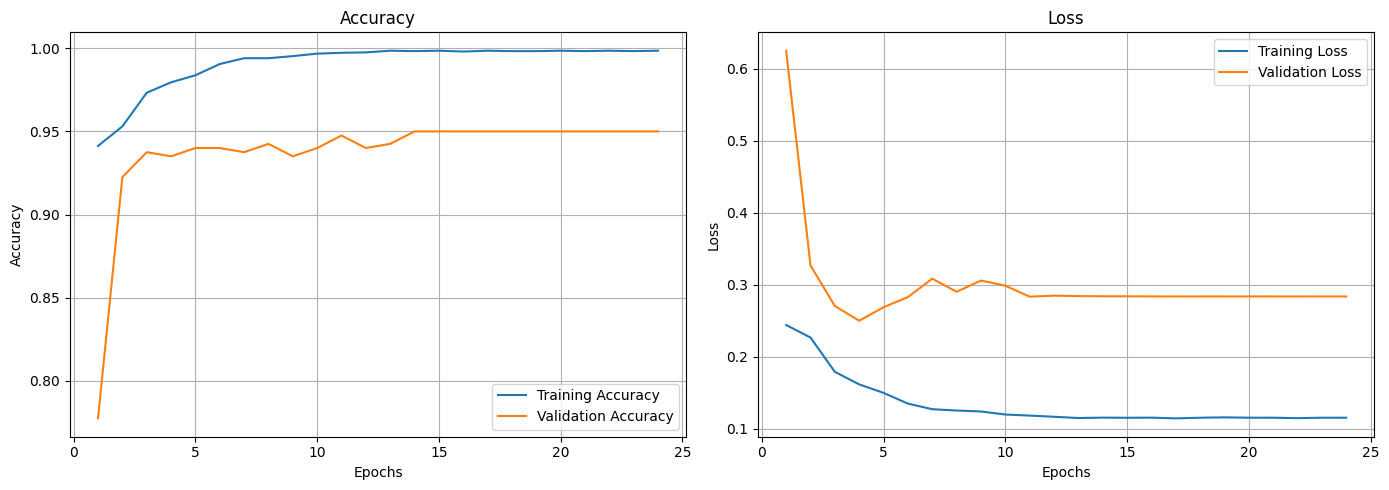

In [45]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# print("Curve 1:")
# -------- Accuracy subplot --------
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# -------- Loss subplot --------
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

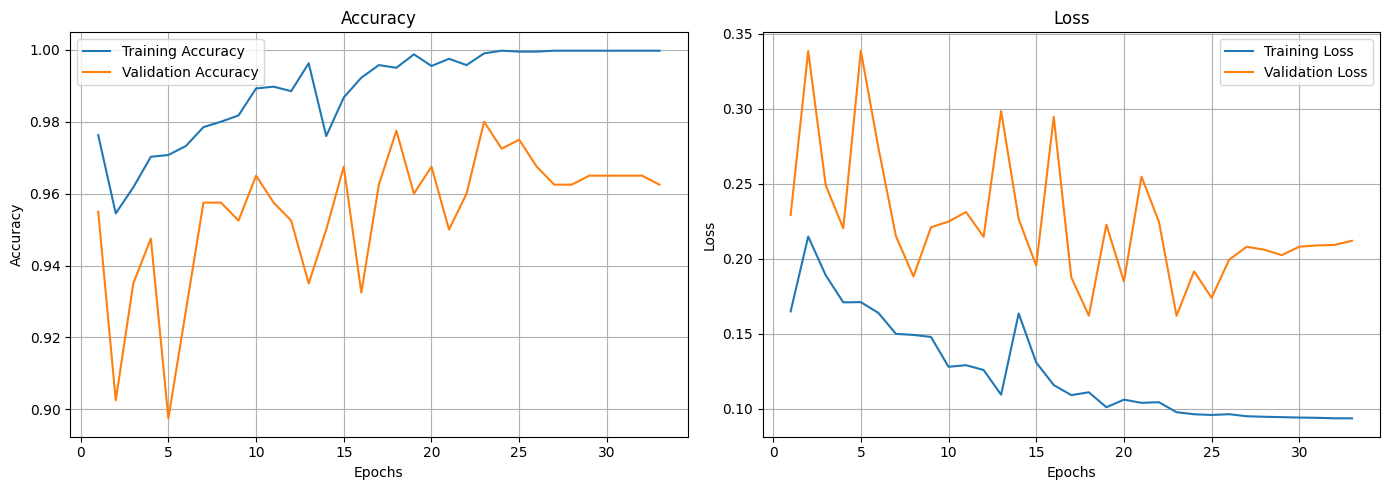

In [46]:
import matplotlib.pyplot as plt

acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']
loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# print("Curve 1:")
# -------- Accuracy subplot --------
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# -------- Loss subplot --------
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

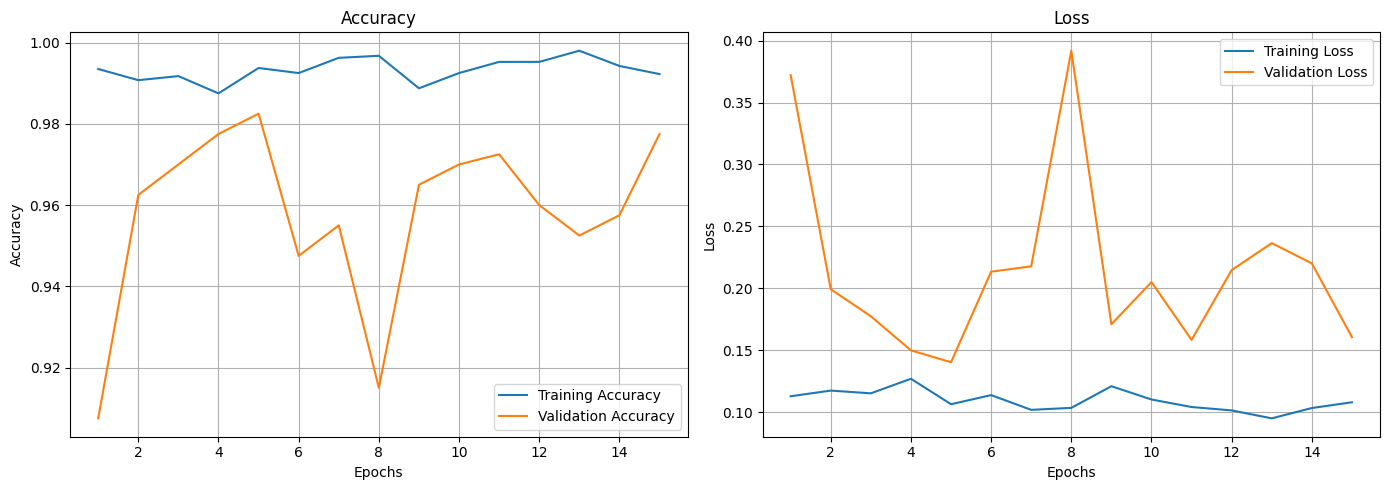

In [49]:
acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']
loss = history3.history['loss']
val_loss = history3.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# print("Curve 1:")
# -------- Accuracy subplot --------
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# -------- Loss subplot --------
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

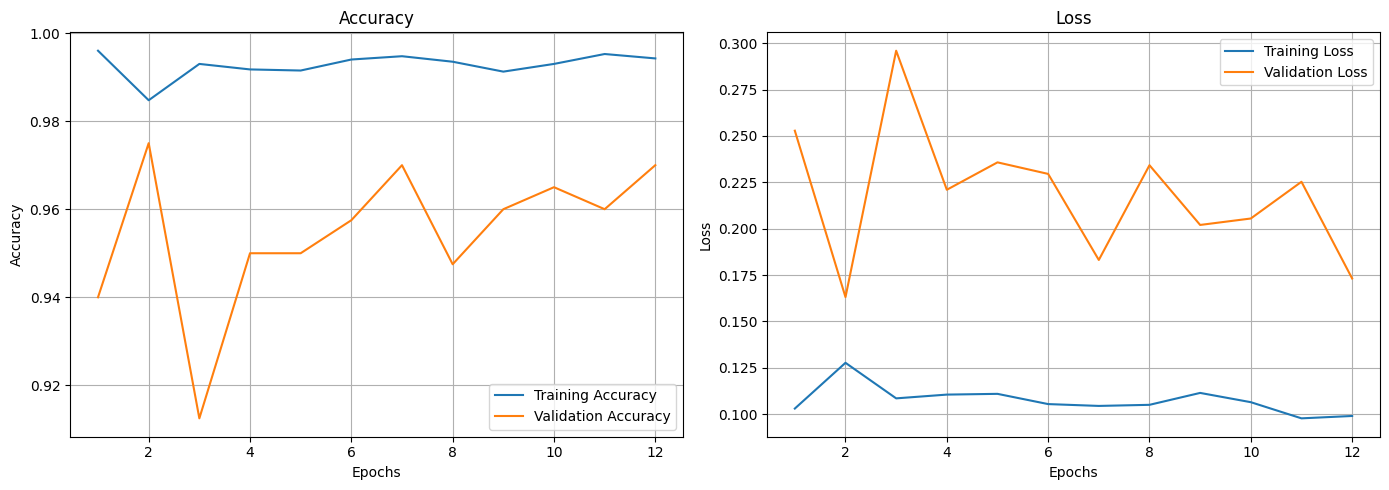

In [50]:
acc = history_h.history['accuracy']
val_acc = history_h.history['val_accuracy']
loss = history_h.history['loss']
val_loss = history_h.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# print("Curve 1:")
# -------- Accuracy subplot --------
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# -------- Loss subplot --------
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Quantizaion

In [51]:
# imports

!pip install tensorflow_model_optimization
import tensorflow_model_optimization as tfmot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 8.7 MB/s eta 0:00:00


## Dynamic Range Quantization

In [64]:
hybrid_model = keras.models.load_model(
    "/kaggle/working/CNN-ViT_Hybrid_Final.keras",
    custom_objects={
        "PatchExtractor": PatchExtractor,
        "ClsTokenLayer": ClsTokenLayer,
        "AddPositionEmbedding": AddPositionEmbedding,
        "transformer_block": transformer_block,
        "WarmUpCosine": WarmUpCosine
    }
)
# Create the TFLite converter
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(hybrid_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Allow both builtin TFLite ops and TensorFlow Select ops
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,      # default TFLite ops
    tf.lite.OpsSet.SELECT_TF_OPS        # allow TF ops fallback (TF Select)
]


tflite_model = converter.convert()
open("CNN-ViT_Hybrid_DRQ.tflite", "wb").write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmplzw9tu5b/assets


INFO:tensorflow:Assets written to: /tmp/tmplzw9tu5b/assets


Saved artifact at '/tmp/tmplzw9tu5b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135719046314896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135719046315088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135719046314704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135719046529488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135719046315664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135719046315472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135719046530640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135719046531216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135719046531408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135719046529104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1357190465298

W0000 00:00:1765322944.556686     746 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1765322944.556724     746 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


2498200

In [65]:


# Function to get probabilities from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class output
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/CNN-ViT_Hybrid_DRQ.tflite")
interpreter.allocate_tensors()


# Find best threshold (Youden’s J statistic) 
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)], y_true, y_prob


thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    return dict(accuracy=accuracy, auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)


print("Validation metrics:", metrics_at_threshold_tflite(interpreter, val_ds, thr))
print("Test metrics:", metrics_at_threshold_tflite(interpreter, test_ds, thr))

I0000 00:00:1765322952.237476     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765322952.237698     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Best threshold: 0.8989151
Validation metrics: {'accuracy': 0.98, 'auc': 0.9941000000000001, 'precision': 0.9897959183673469, 'recall': 0.97, 'f1': 0.9797979797979798, 'specificity': 0.99, 'cm': array([[198,   2],
       [  6, 194]])}
Test metrics: {'accuracy': 0.9725, 'auc': 0.984675, 'precision': 0.9701492537313433, 'recall': 0.975, 'f1': 0.972568578553616, 'specificity': 0.97, 'cm': array([[194,   6],
       [  5, 195]])}


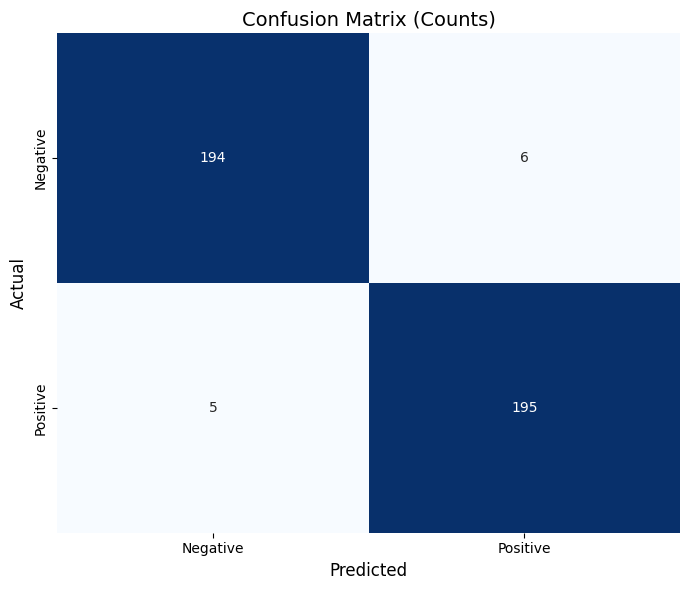

array([[194,   6],
       [  5, 195]])

In [69]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix_tflite(interpreter, dataset, thr,
                                 class_names=["Negative", "Positive"]):

    # Step 1: get predictions
    y_true, y_prob = tflite_predict(interpreter, dataset)
    y_pred = (y_prob >= thr).astype(int)

    # Step 2: build confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Step 3: visualization (raw counts only)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False
    )
    plt.title("Confusion Matrix (Counts)", fontsize=14)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix_tflite(interpreter, test_ds, thr)
cm

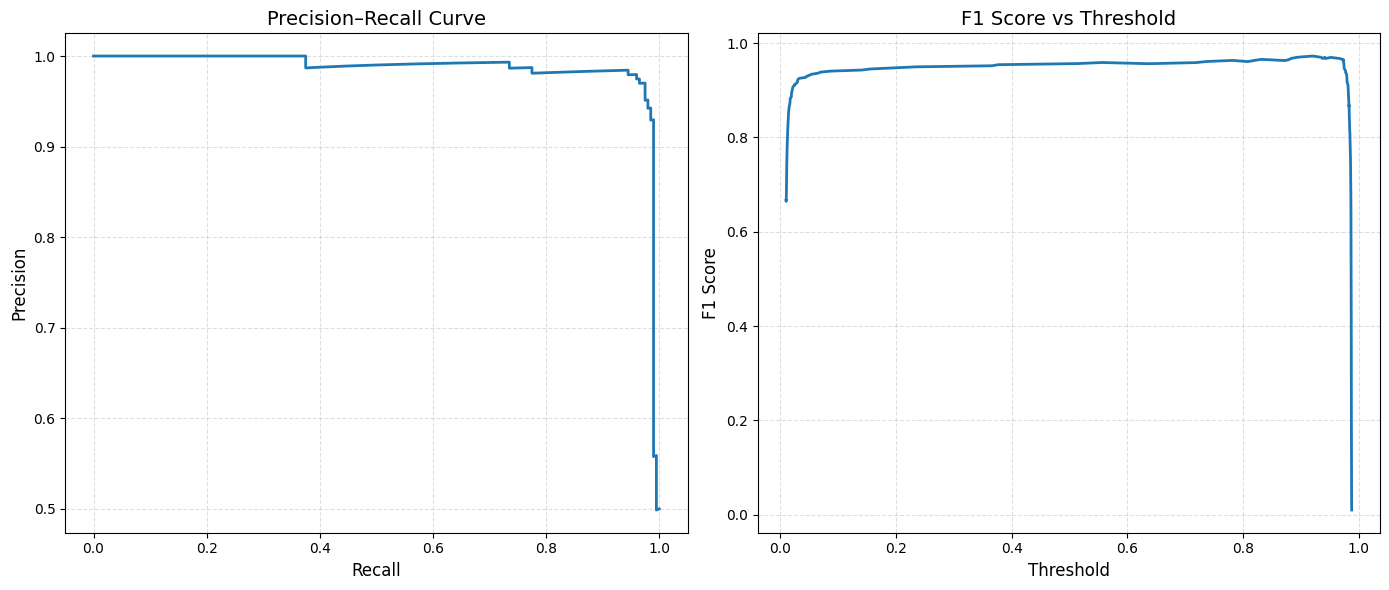

In [70]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_pr_f1_curves(interpreter, dataset):

    # ---------- Step 1: Get true labels & predicted probabilities ----------
    y_true, y_prob = tflite_predict(interpreter, dataset)

    # ---------- Step 2: Precision-Recall ----------
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # ---------- Step 3: F1 vs Threshold ----------
    # Note: precision_recall_curve gives thresholds of size (n-1)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-7)

    # ---------- Step 4: Plot ----------
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # ---- Plot 1: Precision–Recall Curve ----
    ax[0].plot(recalls, precisions, linewidth=2)
    ax[0].set_title("Precision–Recall Curve", fontsize=14)
    ax[0].set_xlabel("Recall", fontsize=12)
    ax[0].set_ylabel("Precision", fontsize=12)
    ax[0].grid(True, linestyle="--", alpha=0.4)

    # ---- Plot 2: F1 Score vs Threshold ----
    ax[1].plot(thresholds, f1_scores, linewidth=2)
    ax[1].set_title("F1 Score vs Threshold", fontsize=14)
    ax[1].set_xlabel("Threshold", fontsize=12)
    ax[1].set_ylabel("F1 Score", fontsize=12)
    ax[1].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    return precisions, recalls, thresholds, f1_scores
    
prec, rec, thr, f1 = plot_pr_f1_curves(interpreter, test_ds)

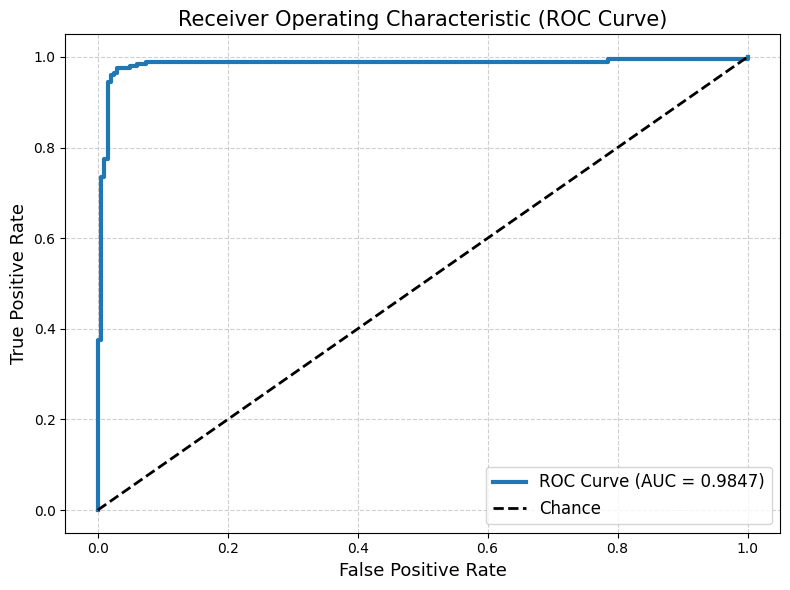

Test AUC: 0.984675


In [72]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve_tflite(interpreter, dataset):
    # Get predictions from your TFLite model
    y_true, y_prob = tflite_predict(interpreter, dataset)

    # Compute ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=3, label=f"ROC Curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label="Chance")

    plt.title("Receiver Operating Characteristic (ROC Curve)", fontsize=15)
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate", fontsize=13)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    return roc_auc

roc_auc_test = plot_roc_curve_tflite(interpreter, test_ds)
print("Test AUC:", roc_auc_test)

## Float 16 Quantization

In [73]:
hybrid_model = keras.models.load_model(
    "/kaggle/working/CNN-ViT_Hybrid_Final.keras",
    custom_objects={
        "PatchExtractor": PatchExtractor,
        "ClsTokenLayer": ClsTokenLayer,
        "AddPositionEmbedding": AddPositionEmbedding,
        "transformer_block": transformer_block,
        "WarmUpCosine": WarmUpCosine
    }
)
# Create the TFLite converter
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(hybrid_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# Allow both builtin TFLite ops and TensorFlow Select ops
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,      # default TFLite ops
    tf.lite.OpsSet.SELECT_TF_OPS        # allow TF ops fallback (TF Select)
]


tflite_model = converter.convert()
open("CNN-ViT_Hybrid_F16.tflite", "wb").write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmp_bdqy28p/assets


INFO:tensorflow:Assets written to: /tmp/tmp_bdqy28p/assets


Saved artifact at '/tmp/tmp_bdqy28p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135752377674512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135752377675088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135752377673744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135752377675856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135752377668368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135752377678160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135752377667984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135752377665680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135752377665296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135752377668752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1357523776733

W0000 00:00:1765324732.672133     746 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1765324732.672165     746 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


4697712

In [74]:


# Function to get probabilities from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class output
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/CNN-ViT_Hybrid_F16.tflite")
interpreter.allocate_tensors()


# Find best threshold (Youden’s J statistic) 
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)], y_true, y_prob


thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    return dict(accuracy=accuracy, auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)


print("Validation metrics:", metrics_at_threshold_tflite(interpreter, val_ds, thr))
print("Test metrics:", metrics_at_threshold_tflite(interpreter, test_ds, thr))

I0000 00:00:1765324759.617193     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765324759.617409     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Best threshold: 0.8934431
Validation metrics: {'accuracy': 0.98, 'auc': 0.994625, 'precision': 0.9897959183673469, 'recall': 0.97, 'f1': 0.9797979797979798, 'specificity': 0.99, 'cm': array([[198,   2],
       [  6, 194]])}
Test metrics: {'accuracy': 0.9675, 'auc': 0.98455, 'precision': 0.9560975609756097, 'recall': 0.98, 'f1': 0.9679012345679012, 'specificity': 0.955, 'cm': array([[191,   9],
       [  4, 196]])}


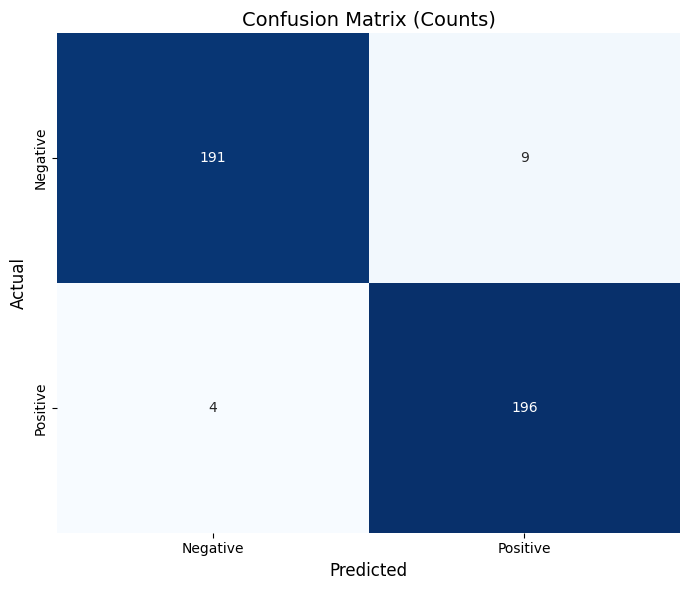

In [75]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix_tflite(interpreter, dataset, thr,
                                 class_names=["Negative", "Positive"]):

    # Step 1: get predictions
    y_true, y_prob = tflite_predict(interpreter, dataset)
    y_pred = (y_prob >= thr).astype(int)

    # Step 2: build confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Step 3: visualization (raw counts only)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False
    )
    plt.title("Confusion Matrix (Counts)", fontsize=14)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix_tflite(interpreter, test_ds, thr)

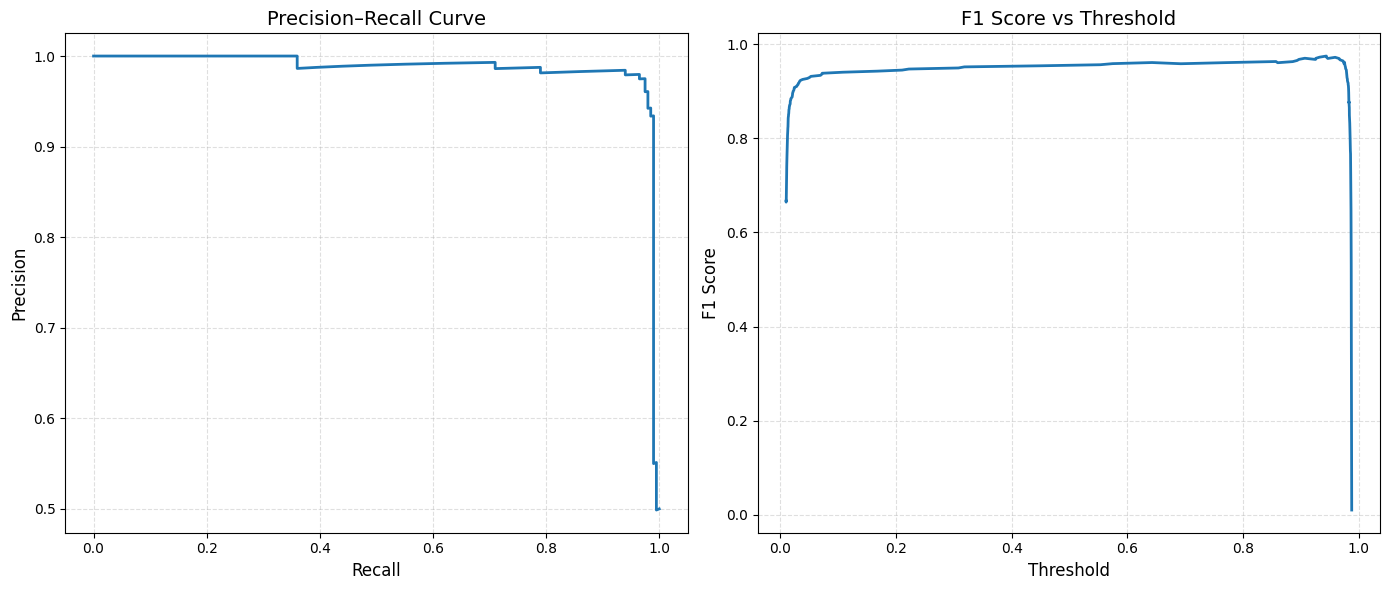

In [76]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_pr_f1_curves(interpreter, dataset):

    # ---------- Step 1: Get true labels & predicted probabilities ----------
    y_true, y_prob = tflite_predict(interpreter, dataset)

    # ---------- Step 2: Precision-Recall ----------
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # ---------- Step 3: F1 vs Threshold ----------
    # Note: precision_recall_curve gives thresholds of size (n-1)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-7)

    # ---------- Step 4: Plot ----------
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # ---- Plot 1: Precision–Recall Curve ----
    ax[0].plot(recalls, precisions, linewidth=2)
    ax[0].set_title("Precision–Recall Curve", fontsize=14)
    ax[0].set_xlabel("Recall", fontsize=12)
    ax[0].set_ylabel("Precision", fontsize=12)
    ax[0].grid(True, linestyle="--", alpha=0.4)

    # ---- Plot 2: F1 Score vs Threshold ----
    ax[1].plot(thresholds, f1_scores, linewidth=2)
    ax[1].set_title("F1 Score vs Threshold", fontsize=14)
    ax[1].set_xlabel("Threshold", fontsize=12)
    ax[1].set_ylabel("F1 Score", fontsize=12)
    ax[1].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    return precisions, recalls, thresholds, f1_scores
    
prec, rec, thr, f1 = plot_pr_f1_curves(interpreter, test_ds)

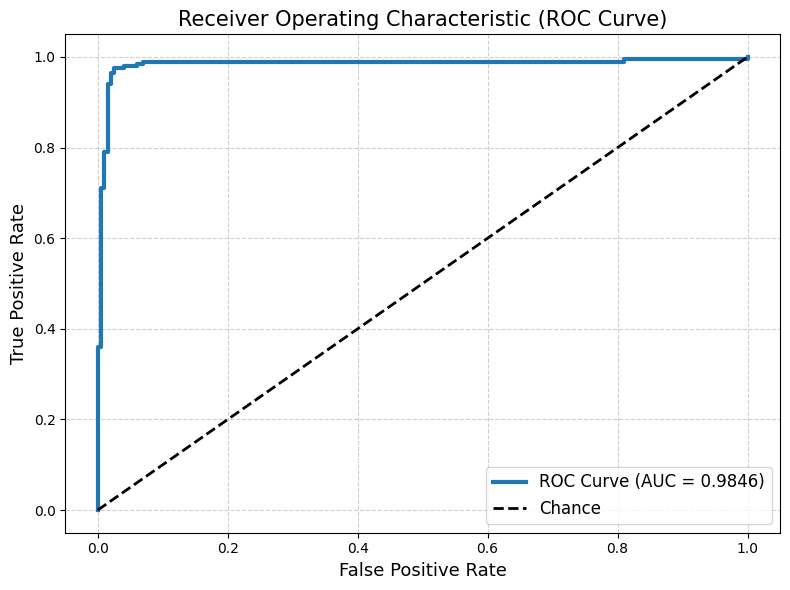

Test AUC: 0.98455


In [77]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve_tflite(interpreter, dataset):
    # Get predictions from your TFLite model
    y_true, y_prob = tflite_predict(interpreter, dataset)

    # Compute ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=3, label=f"ROC Curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label="Chance")

    plt.title("Receiver Operating Characteristic (ROC Curve)", fontsize=15)
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate", fontsize=13)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    return roc_auc

roc_auc_test = plot_roc_curve_tflite(interpreter, test_ds)
print("Test AUC:", roc_auc_test)

## XAI integration

## Load the dataset again

In [83]:
# Load dataset

def build_ds(subdir, augment=False, shuffle=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(root, subdir),
        labels="inferred",
        label_mode="int",
        color_mode="rgb",
        batch_size=BATCH,
        image_size=IMG_SIZE,
        shuffle=shuffle,
        seed=SEED
    )

    aug = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.05),
        layers.RandomContrast(0.1),
        layers.RandomZoom(0.1)
    ]) if augment else None

    def _map(x, y):
        x = tf.cast(x, tf.float32) 
        if aug is not None:
            x = aug(x, training=True)
            
        # x = layers.Rescaling(1./255)(x)
        return x, y

    return (ds.map(_map, num_parallel_calls=AUTOTUNE)
              .cache()
              .prefetch(AUTOTUNE))

train_ds2 = build_ds("train", augment=True, shuffle=True)
val_ds2   = build_ds("validation", augment=False, shuffle=False)
test_ds2  = build_ds("test", augment=False, shuffle=False)

Found 4000 files belonging to 2 classes.
Found 400 files belonging to 2 classes.
Found 400 files belonging to 2 classes.


## DRQ model

I0000 00:00:1765328827.026245     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765328827.026455     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TFLite model loaded successfully!
Computed best threshold = 0.06
Skipping image 4: Predicted NEG (prob=0.035)
Skipping image 7: Predicted NEG (prob=0.016)
Skipping image 8: Predicted NEG (prob=0.027)
Skipping image 10: Predicted NEG (prob=0.019)
Skipping image 12: Predicted NEG (prob=0.020)
Skipping image 16: Predicted NEG (prob=0.039)
Skipping image 17: Predicted NEG (prob=0.034)
Skipping image 21: Predicted NEG (prob=0.015)
Skipping image 22: Predicted NEG (prob=0.026)
Skipping image 28: Predicted NEG (prob=0.019)
Skipping image 31: Predicted NEG (prob=0.036)
Skipping image 34: Predicted NEG (prob=0.025)
Skipping image 36: Predicted NEG (prob=0.035)
Skipping image 38: Predicted NEG (prob=0.032)
Skipping image 40: Predicted NEG (prob=0.017)
Skipping image 41: Predicted NEG (prob=0.024)
Skipping image 43: Predicted NEG (prob=0.049)
Skipping image 44: Predicted NEG (prob=0.021)
Skipping image 46: Predicted NEG (prob=0.039)
Skipping image 48: Predicted NEG (prob=0.031)
Skipping image 53:

  0%|          | 0/400 [00:00<?, ?it/s]

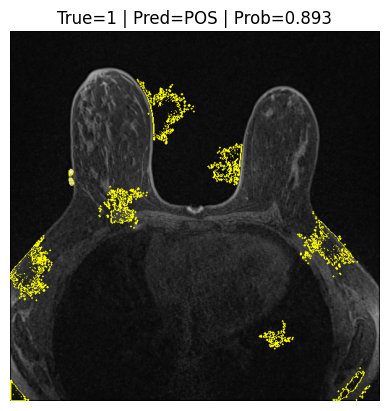

Explaining image 201: True=1, Pred=POS (prob=0.921)


  0%|          | 0/400 [00:00<?, ?it/s]

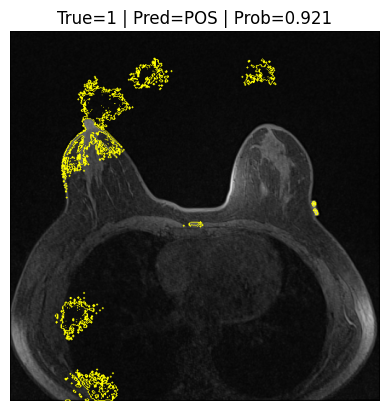

Explaining image 202: True=1, Pred=POS (prob=0.613)


  0%|          | 0/400 [00:00<?, ?it/s]

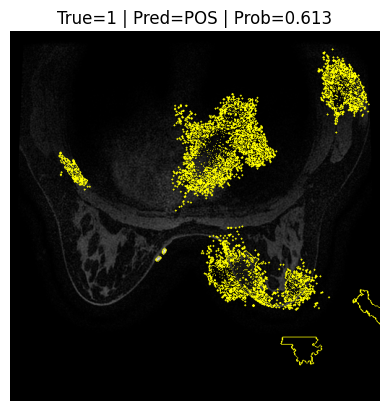

Skipping image 203: Predicted NEG (prob=0.045)
Explaining image 204: True=1, Pred=POS (prob=0.160)


  0%|          | 0/400 [00:00<?, ?it/s]

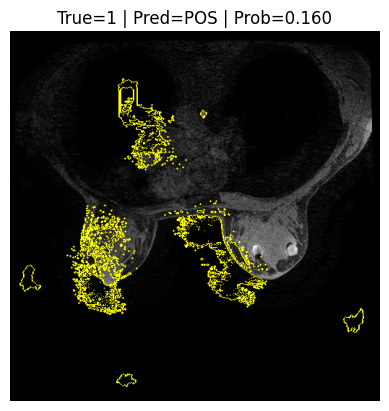

Explaining image 205: True=1, Pred=POS (prob=0.305)


  0%|          | 0/400 [00:00<?, ?it/s]

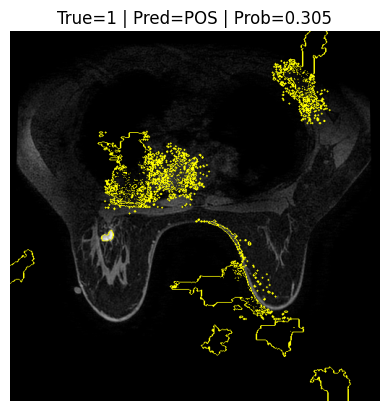

Explaining image 206: True=1, Pred=POS (prob=0.314)


  0%|          | 0/400 [00:00<?, ?it/s]

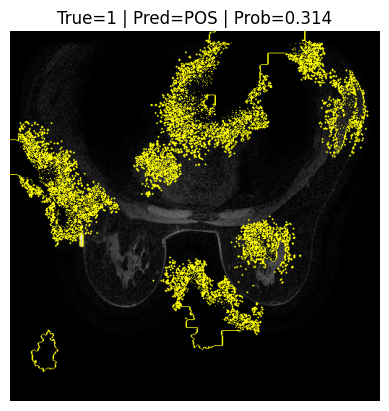

Explaining image 207: True=1, Pred=POS (prob=0.981)


  0%|          | 0/400 [00:00<?, ?it/s]

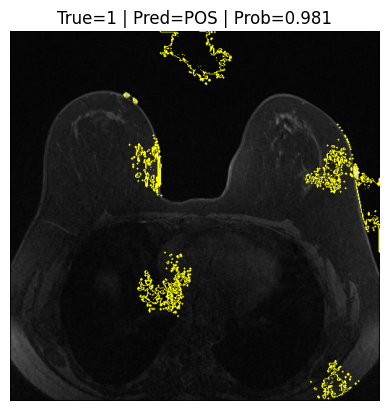

Explaining image 208: True=1, Pred=POS (prob=0.067)


  0%|          | 0/400 [00:00<?, ?it/s]

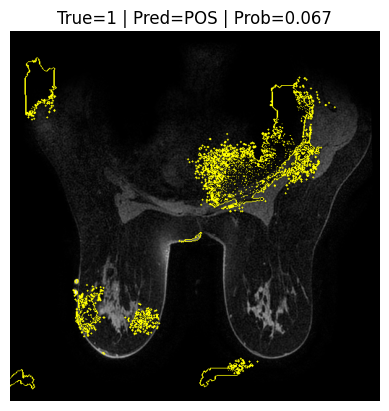

Explaining image 209: True=1, Pred=POS (prob=0.982)


  0%|          | 0/400 [00:00<?, ?it/s]

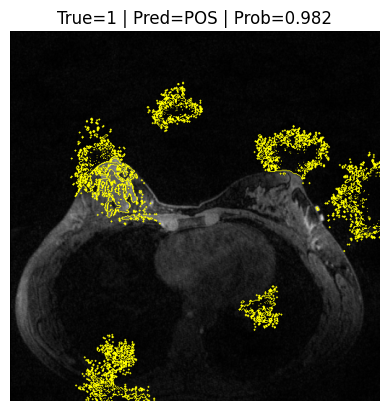

Explaining image 210: True=1, Pred=POS (prob=0.183)


  0%|          | 0/400 [00:00<?, ?it/s]

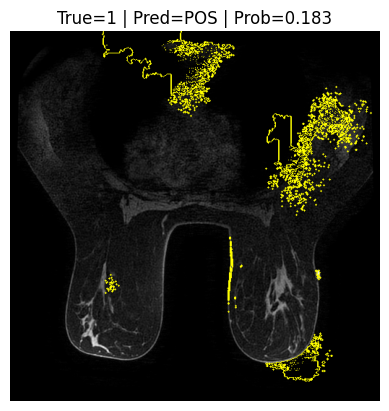


Done explaining 10 positive images (checked 211 total).


In [85]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

interpreter = tf.lite.Interpreter(model_path="/kaggle/working/CNN-ViT_Hybrid_DRQ.tflite")
interpreter.allocate_tensors()
print("TFLite model loaded successfully!")


# Integrate LIME XAI

# prediction func
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]
            y_true.append(int(label))
            y_prob.append(float(prob))
    return np.array(y_true), np.array(y_prob)

try:
    y_true_val, y_prob_val = tflite_predict(interpreter, val_ds2)
    fpr, tpr, thr = roc_curve(y_true_val, y_prob_val)
    best_thr = thr[np.argmax(tpr - fpr)]
    print(f"Computed best threshold = {best_thr:.2f}")
except Exception as e:
    print("Could not compute threshold, using 0.55. Error:", e)
    best_thr = 0.55


# xai func
def tflite_predict_xai(images: np.ndarray):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    out_probs = []
    for img in images:
        img_in = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_index, img_in)
        interpreter.invoke()
        output = interpreter.get_tensor(output_index)[0]
        if output.shape[0] == 2:
            prob1 = tf.nn.softmax(output).numpy()[1]
        else:
            prob1 = float(output[0])
        prob0 = 1.0 - prob1
        out_probs.append([prob0, prob1])
    return np.array(out_probs)


explainer = lime_image.LimeImageExplainer()

# explainer func (true pos only)
def explain_and_plot(img, true_label, idx=0, num_samples=400):
    # Model prediction (via wrapper)
    probs = tflite_predict_xai(img[np.newaxis, ...])[0]
    prob_pos = float(np.squeeze(probs[1]))  
    pred_label = pred_label = int(prob_pos >= best_thr)

    # Skip negatives
    if pred_label == 0:
        print(f"Skipping image {idx}: Predicted NEG (prob={prob_pos:.3f})")
        return False

    # only true positives:
    if not (pred_label == 1 and true_label == 1):
        return False

    print(f"Explaining image {idx}: True={true_label}, Pred=POS (prob={prob_pos:.3f})")

    explanation = explainer.explain_instance(
        image=img.astype('double'),
        classifier_fn=tflite_predict_xai,
        labels=(1,),
        hide_color=0,
        num_samples=num_samples
    )

    temp, mask = explanation.get_image_and_mask(
        label=1,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title(f"True={true_label} | Pred=POS | Prob={prob_pos:.3f}")
    plt.axis("off")
    plt.show()

    return True


# run xai for 10 images
max_images = 10
count = 0
attempts = 0

for x_batch, y_batch in test_ds2.unbatch().batch(1).take(400):
    img = x_batch[0].numpy()
    true_label = int(y_batch[0].numpy())

    explained = explain_and_plot(img, true_label, idx=attempts, num_samples=400)
    attempts += 1
    if explained:
        count += 1
    if count >= max_images:
        break

print(f"\nDone explaining {count} positive images (checked {attempts} total).")

## F16

I0000 00:00:1765330960.939861     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765330960.940078     746 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TFLite model loaded successfully!
Computed best threshold = 0.09
Skipping image 4: Predicted NEG (prob=0.028)
Skipping image 5: Predicted NEG (prob=0.037)
Skipping image 6: Predicted NEG (prob=0.062)
Skipping image 7: Predicted NEG (prob=0.015)
Skipping image 8: Predicted NEG (prob=0.016)
Skipping image 10: Predicted NEG (prob=0.020)
Skipping image 12: Predicted NEG (prob=0.019)
Skipping image 16: Predicted NEG (prob=0.029)
Skipping image 17: Predicted NEG (prob=0.026)
Skipping image 18: Predicted NEG (prob=0.046)
Skipping image 19: Predicted NEG (prob=0.076)
Skipping image 21: Predicted NEG (prob=0.015)
Skipping image 22: Predicted NEG (prob=0.015)
Skipping image 25: Predicted NEG (prob=0.074)
Skipping image 28: Predicted NEG (prob=0.016)
Skipping image 31: Predicted NEG (prob=0.039)
Skipping image 32: Predicted NEG (prob=0.072)
Skipping image 34: Predicted NEG (prob=0.020)
Skipping image 35: Predicted NEG (prob=0.078)
Skipping image 36: Predicted NEG (prob=0.026)
Skipping image 37: P

  0%|          | 0/400 [00:00<?, ?it/s]

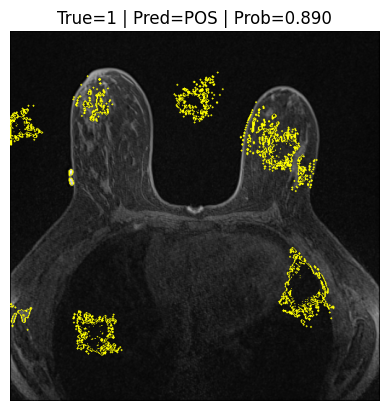

Explaining image 201: True=1, Pred=POS (prob=0.895)


  0%|          | 0/400 [00:00<?, ?it/s]

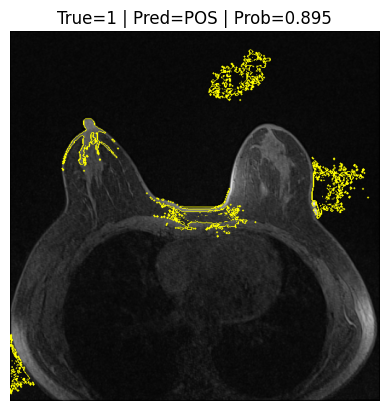

Explaining image 202: True=1, Pred=POS (prob=0.198)


  0%|          | 0/400 [00:00<?, ?it/s]

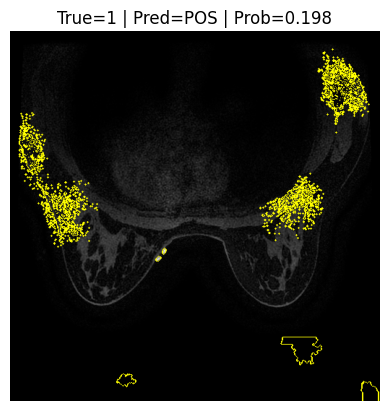

Explaining image 203: True=1, Pred=POS (prob=0.095)


  0%|          | 0/400 [00:00<?, ?it/s]

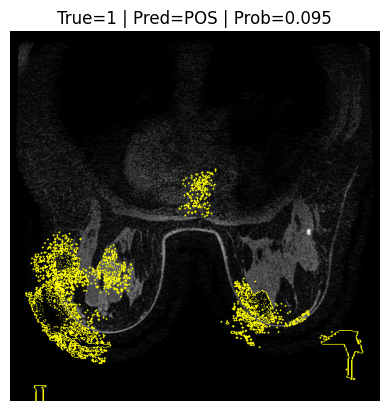

Explaining image 204: True=1, Pred=POS (prob=0.360)


  0%|          | 0/400 [00:00<?, ?it/s]

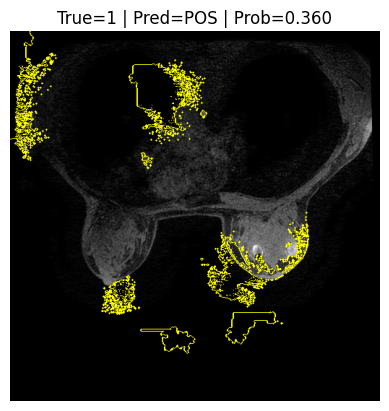

Explaining image 205: True=1, Pred=POS (prob=0.311)


  0%|          | 0/400 [00:00<?, ?it/s]

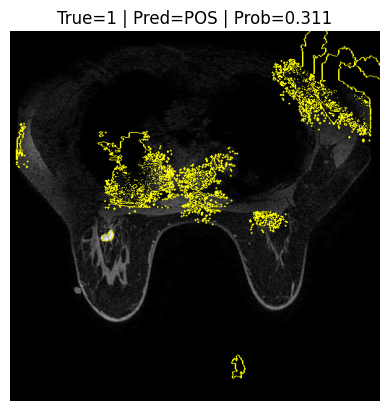

Explaining image 206: True=1, Pred=POS (prob=0.312)


  0%|          | 0/400 [00:00<?, ?it/s]

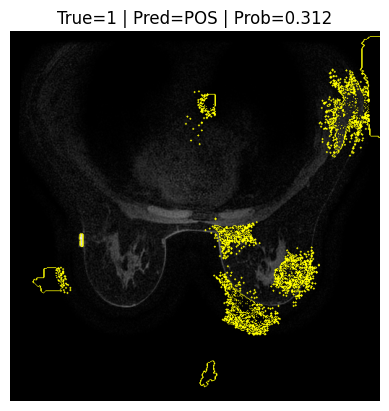

Explaining image 207: True=1, Pred=POS (prob=0.981)


  0%|          | 0/400 [00:00<?, ?it/s]

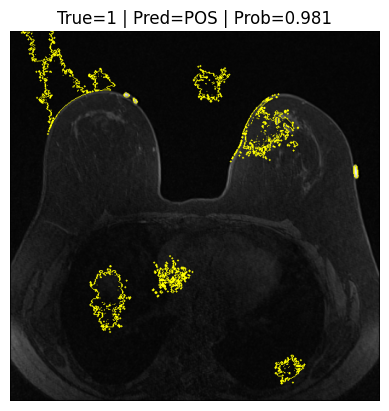

Skipping image 208: Predicted NEG (prob=0.083)
Explaining image 209: True=1, Pred=POS (prob=0.982)


  0%|          | 0/400 [00:00<?, ?it/s]

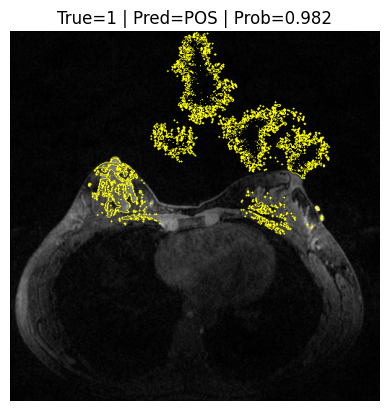

Explaining image 210: True=1, Pred=POS (prob=0.236)


  0%|          | 0/400 [00:00<?, ?it/s]

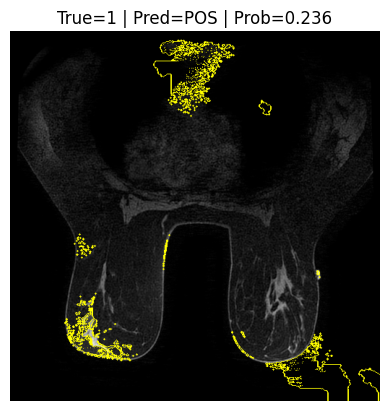


Done explaining 10 positive images (checked 211 total).


In [87]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

interpreter = tf.lite.Interpreter(model_path="/kaggle/working/CNN-ViT_Hybrid_F16.tflite")
interpreter.allocate_tensors()
print("TFLite model loaded successfully!")


# Integrate LIME XAI

# prediction func
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]
            y_true.append(int(label))
            y_prob.append(float(prob))
    return np.array(y_true), np.array(y_prob)

try:
    y_true_val, y_prob_val = tflite_predict(interpreter, val_ds2)
    fpr, tpr, thr = roc_curve(y_true_val, y_prob_val)
    best_thr = thr[np.argmax(tpr - fpr)]
    print(f"Computed best threshold = {best_thr:.2f}")
except Exception as e:
    print("Could not compute threshold, using 0.55. Error:", e)
    best_thr = 0.55


# xai func
def tflite_predict_xai(images: np.ndarray):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    out_probs = []
    for img in images:
        img_in = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_index, img_in)
        interpreter.invoke()
        output = interpreter.get_tensor(output_index)[0]
        if output.shape[0] == 2:
            prob1 = tf.nn.softmax(output).numpy()[1]
        else:
            prob1 = float(output[0])
        prob0 = 1.0 - prob1
        out_probs.append([prob0, prob1])
    return np.array(out_probs)


explainer = lime_image.LimeImageExplainer()

# explainer func (true pos only)
def explain_and_plot(img, true_label, idx=0, num_samples=400):
    # Model prediction (via wrapper)
    probs = tflite_predict_xai(img[np.newaxis, ...])[0]
    prob_pos = float(np.squeeze(probs[1]))  
    pred_label = pred_label = int(prob_pos >= best_thr)

    # Skip negatives
    if pred_label == 0:
        print(f"Skipping image {idx}: Predicted NEG (prob={prob_pos:.3f})")
        return False

    # only true positives:
    if not (pred_label == 1 and true_label == 1):
        return False

    print(f"Explaining image {idx}: True={true_label}, Pred=POS (prob={prob_pos:.3f})")

    explanation = explainer.explain_instance(
        image=img.astype('double'),
        classifier_fn=tflite_predict_xai,
        labels=(1,),
        hide_color=0,
        num_samples=num_samples
    )

    temp, mask = explanation.get_image_and_mask(
        label=1,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title(f"True={true_label} | Pred=POS | Prob={prob_pos:.3f}")
    plt.axis("off")
    plt.show()

    return True


# run xai for 10 images
max_images = 10
count = 0
attempts = 0

for x_batch, y_batch in test_ds2.unbatch().batch(1).take(400):
    img = x_batch[0].numpy()
    true_label = int(y_batch[0].numpy())

    explained = explain_and_plot(img, true_label, idx=attempts, num_samples=400)
    attempts += 1
    if explained:
        count += 1
    if count >= max_images:
        break

print(f"\nDone explaining {count} positive images (checked {attempts} total).")

## Model sizes

In [88]:
files = [
    "/kaggle/working/CNN-ViT_Hybrid_Final.keras",
    "/kaggle/working/CNN-ViT_Hybrid_DRQ.tflite",
    "/kaggle/working/CNN-ViT_Hybrid_F16.tflite",
]

for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"{f}: {size_mb:.2f} MB")

/kaggle/working/CNN-ViT_Hybrid_Final.keras: 26.78 MB
/kaggle/working/CNN-ViT_Hybrid_DRQ.tflite: 2.38 MB
/kaggle/working/CNN-ViT_Hybrid_F16.tflite: 4.48 MB
